<a href="https://colab.research.google.com/github/Yelmi95/IA_SIS420/blob/main/Lab01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratorio 1 — Regresión Lineal Multivariable**
**Nombre:** Yulitza Alcibia Miranda

Grupo: 2

 **Dataset:** Student Productivity & Digital Distraction Dataset

 **Descripción del Dataset**

El dataset contiene información sobre **20,000 estudiantes**, con **16 columnas**
que incluyen características de hábitos académicos, comportamiento digital
y métricas de rendimiento y productividad.

**Variable objetivo**
Se predice **`productivity_score`** — puntuación de productividad general
del estudiante (0-100), en base a sus hábitos de estudio, sueño, uso del
teléfono, redes sociales, videojuegos y rendimiento académico.

**Modelos implementados**
- Regresión Lineal Multivariable con **Ecuación Normal** (solución analítica directa)
- Regresión Lineal Multivariable con **Descenso por Gradiente** (solución iterativa)


CELDA1- Importación de librerías

In [ ]:
# Librería para manejo de directorios y rutas
import os

# Librería para computación vectorial y científica
import numpy as np

# Librería para graficar
from matplotlib import pyplot

# Permite mostrar las gráficas dentro del cuadernillo
%matplotlib inline

 CELDA 2 — Conectar Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# CELDA 3 — Cargar el dataset
Se carga el archivo `student_productivity_distraction_dataset_20000.csv` desde
**Google Drive** utilizando `numpy.loadtxt`. Se omiten las columnas `student_id`
y `gender` por ser un identificador y una variable de texto respectivamente,
trabajando con **15 variables numéricas** como predictoras y `productivity_score`
como variable objetivo, obteniendo un total de **20,000 ejemplos** de entrenamiento.


In [ ]:
data = np.loadtxt('/content/drive/MyDrive/IA_sis420/LABORATORIOS/DATASET/student_productivity_distraction_dataset_20000.csv',
                   delimiter=',',
                   skiprows=1,
                   usecols=(1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17))

# Separamos X (variables predictoras) e y (variable a predecir)
X = data[:, :15]
y = data[:, 15]

m = y.size

print('Numero de ejemplos (m):', m)
print('Numero de variables (X):', X.shape[1])


print('{:>8s}{:>10s}{:>12s}{:>14s}{:>14s}{:>10s}{:>10s}{:>8s}{:>8s}{:>10s}{:>12s}{:>13s}{:>8s}{:>13s}{:>12s}{:>10s}'.format(
'X[:,0]',
'X[:,1]',
'X[:,2]',
'X[:,3]',
'X[:,4]',
'X[:,5]',
'X[:,6]',
'X[:,7]',
'X[:,8]',
'X[:,9]',
'X[:,10]',
'X[:,11]',
'X[:,12]',
'X[:,13]',
'X[:,14]',
'y'
))
print('-' * 170)
for i in range(10):
    print('{:8.0f}{:10.0f}{:12.0f}{:14.0f}{:14.0f}{:10.0f}{:10.0f}{:8.0f}{:8.0f}{:10.0f}{:12.0f}{:13.0f}{:8.0f}{:13.0f}{:12.0f}{:10.0f}'.format(
        X[i, 0],   # age
        X[i, 1],   # study_hours_per_day
        X[i, 2],   # sleep_hours
        X[i, 3],   # phone_usage_hours
        X[i, 4],   # social_media_hours
        X[i, 5],   # youtube_hours
        X[i, 6],   # gaming_hours
        X[i, 7],   # breaks_per_day
        X[i, 8],   # coffee_intake_mg
        X[i, 9],   # exercise_minutes
        X[i, 10],  # assignments_completed
        X[i, 11],  # attendance_percentage
        X[i, 12],  # stress_level
        X[i, 13],  # focus_score
        X[i, 14],  # final_grade
        y[i]))

Numero de ejemplos (m): 20000
Numero de variables (X): 15
  X[:,0]    X[:,1]      X[:,2]        X[:,3]        X[:,4]    X[:,5]    X[:,6]  X[:,7]  X[:,8]    X[:,9]     X[:,10]      X[:,11] X[:,12]      X[:,13]     X[:,14]         y
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
      23         4           4             3             3         2         5       6     347       111           2           57      10           57          82        34
      20         6           7             5             2         3         2      13     403        28          10           91      10           49          61        49
      29         5           3             5             4         0         5       1     419       102           8           63       2           38          86        37
      27         3           5            10             4         6         3 

## 1. Ecuacion de la Normal

Una manera de calcular rápidamente el modelo de una regresión lineal es:

$$ \theta = \left( X^T X\right)^{-1} X^T\vec{y} $$

Utilizar esta formula **no requiere que se escale ninguna caracteristica**, y se obtendra una solucion exacta con un solo calculo: no hay bucles de convergencia como en el descenso por el gradiente.

Primero se recargan los datos para garantizar que las variables no esten modificadas. Recordar que no es necesario escalar las caracteristicas, se debe agregar la columna de unos a la matriz $X$ para tener el termino de interseccion ($\theta_0$).

CELDA 4 — Añadir intersección


In [ ]:
# Añade columna de unos para theta_0
X_normal = np.concatenate([np.ones((m, 1)), X], axis=1)
print('Forma de X con interseccion:', X_normal.shape)

Forma de X con interseccion: (20000, 16)


CELDA 5 - Se aplica la ecuación de la normal para obtener los valores de theta

In [ ]:
def normalEqn(X, y):
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)

    return theta

theta_normal = normalEqn(X_normal, y)
print('Theta calculado por la ecuacion normal:')
print(theta_normal)

Theta calculado por la ecuacion normal:
[-6.23876093e+00  2.13657219e-06  4.31638666e+00  2.69774800e+00
 -1.61863664e+00 -2.98817271e-06  1.01512208e-05  1.59894922e-05
 -2.22263657e-06  2.18478641e-07  7.07812455e-07 -6.04630618e-06
  1.61863518e-01 -1.07909668e+00  3.23728786e-01 -1.84259208e-06]


CELDA 6 — Predicción

In [ ]:
# Predecir productividad de un nuevo estudiante

nuevo_estudiante = np.array([1, 20, 10, 7, 2, 1, 1, 0, 4, 100, 45, 8, 90, 3, 75, 85])

productividad_normal = np.dot(nuevo_estudiante, theta_normal)
print('Productividad predicha: {:.2f}'.format(productividad_normal))

Productividad predicha: 88.18


## Regresión Lineal Multivariable con Descenso por Gradiente

A diferencia de la Ecuación Normal que calcula los parámetros **θ** de forma
directa, el Descenso por Gradiente es un algoritmo iterativo que encuentra
los parámetros óptimos dando pequeños pasos en la dirección que reduce el error.
Para aplicar este método correctamente se deben seguir los siguientes pasos:
**normalizar** las variables para que estén en la misma escala, **inicializar**
los parámetros θ en cero, y repetir la actualización de θ durante un número
determinado de iteraciones hasta que el costo **converja** al mínimo.


Recargar datos

In [ ]:
data2 = np.loadtxt('/content/drive/MyDrive/IA_sis420/LABORATORIOS/DATASET/student_productivity_distraction_dataset_20000.csv',
                   delimiter=',',
                   skiprows=1,
                   usecols=(1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17))


X2 = data2[:, :15]
y2 = data2[:, 15]


m2 = y2.size

print('Numero de ejemplos (m):', m2)
print('Numero de variables (X):', X2.shape[1])



print('-' * 170)
for i in range(10):
    print('{:8.0f}{:10.0f}{:12.0f}{:14.0f}{:14.0f}{:10.0f}{:10.0f}{:8.0f}{:8.0f}{:10.0f}{:12.0f}{:13.0f}{:8.0f}{:13.0f}{:12.0f}{:10.0f}'.format(
         X2[i,0],
        X2[i,1],
        X2[i,2],
        X2[i,3],
        X2[i,4],
        X2[i,5],
        X2[i,6],
        X2[i,7],
        X2[i,8],
        X2[i,9],
        X2[i,10],
        X2[i,11],
        X2[i,12],
        X2[i,13],
        X2[i,14],
        y2[i]))

Numero de ejemplos (m): 20000
Numero de variables (X): 15
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
      23         4           4             3             3         2         5       6     347       111           2           57      10           57          82        34
      20         6           7             5             2         3         2      13     403        28          10           91      10           49          61        49
      29         5           3             5             4         0         5       1     419       102           8           63       2           38          86        37
      27         3           5            10             4         6         3       9     178        28          18           41       6           50          72        20
      24         8           6             3             2         5         6 

###  Normalización de Variables

Dado que las variables tienen escalas muy diferentes — por ejemplo
`coffee_intake_mg` puede llegar a 500 mientras `gaming_hours` va de 0 a 6
es necesario normalizar para que ninguna variable domine sobre las demás.

In [ ]:
def featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [ ]:
# Llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X2)

print(X2)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

[[23.    4.35  3.63 ... 10.   57.   81.87]
 [20.    6.14  6.58 ... 10.   49.   60.9 ]
 [29.    4.98  3.26 ...  2.   38.   86.22]
 ...
 [25.    9.36  4.33 ...  9.   69.   81.58]
 [22.    0.74  4.44 ...  5.   53.   53.04]
 [19.    3.64  6.35 ...  9.   65.   72.7 ]]
Media calculada: [ 23.00745     5.2545615   6.5177985   6.250479    4.0036555   2.990177
   2.988339    7.5424    249.65455    59.64805     9.4941     69.9474355
   5.47875    64.44435    70.266409 ]
Desviación estandar calculada: [  3.7547962    2.74280759   2.02973304   3.312999     2.30509626
   1.72977149   1.73276013   4.01613026 143.70763833  34.6108853
   5.80132443  17.39699614   2.86687084  20.17560911  17.28184455]
[[-0.00198413 -0.32979401 -1.42274794 ...  1.57706791 -0.36897771
   0.67143244]
 [-0.80096225  0.32282195  0.03064516 ...  1.57706791 -0.7654961
  -0.5419797 ]
 [ 1.59597211 -0.10010236 -1.60503792 ... -1.21343102 -1.31070888
   0.92314168]
 ...
 [ 0.53066795  1.4968015  -1.077875   ...  1.22825554  0.225

Añadir término de intersección

In [ ]:
X = np.concatenate([np.ones((m2, 1)), X_norm], axis=1)

print('Nueva forma de X con termino de interseccion:', X.shape)

Nueva forma de X con termino de interseccion: (20000, 16)


Funcion de Costo
Utilizamos la función de Costo porque mide qué tan equivocadas están las predicciones
del modelo. Cuanto mayor sea el costo, peor es el modelo.

In [ ]:
def computeCostMulti(X, y, theta):
    # Numero de ejemplos de entrenamiento
    m = y.shape[0]
    J = 0
    h = np.dot(X, theta)

    J = (1 / (2 * m)) * np.sum(np.square(h - y))

    return J

In [ ]:
# Prueba la funcion de costo con theta = ceros
theta = np.zeros(16)

costo_inicial = computeCostMulti(X, y2, theta)
print('Costo inicial (theta = ceros):', costo_inicial)

Costo inicial (theta = ceros): 1388.4211432125


### Descenso por Gradiente

El algoritmo actualiza los parámetros **θ** en cada iteración usando la fórmula
**θ = θ - (α/m) * Xᵀ(Xθ - y)**, donde **α** es la tasa de aprendizaje que
controla el tamaño del paso. Se utiliza **α = 0.1** y **400 iteraciones**,
valores que permiten al modelo converger al mínimo de forma estable y eficiente.

In [ ]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = len(y)
    J_history = []
    accuracy_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * X.T.dot(X.dot(theta) - y)
        J_history.append(computeCostMulti(X, y, theta))

        # Calcular precision en cada iteracion
        y_pred = X.dot(theta)
        y_pred_redondeado = np.round(y_pred)
        correctas = np.sum(y_pred_redondeado == y)
        precision = (correctas / m) * 100
        accuracy_history.append(precision)

    return theta, J_history, accuracy_history

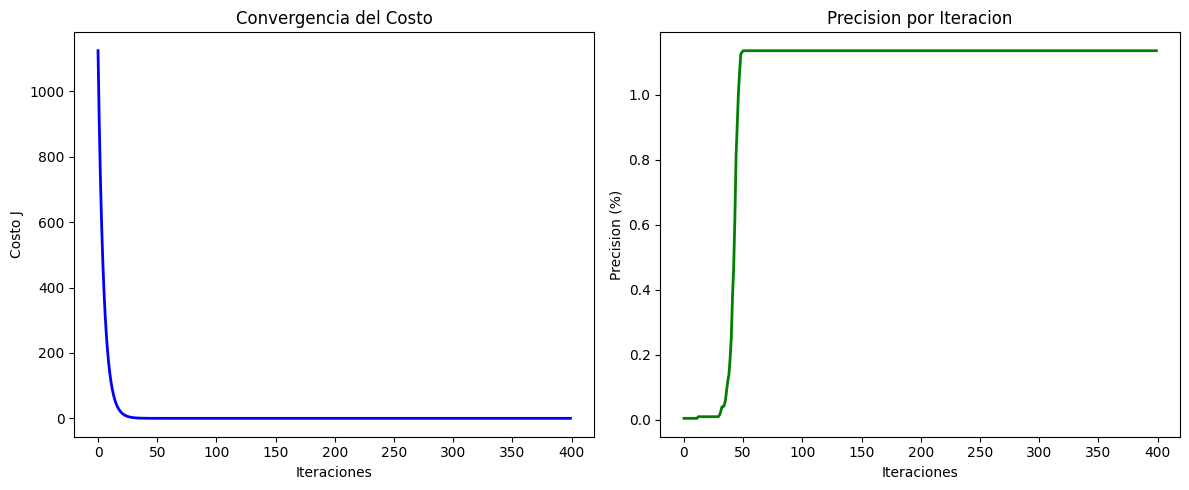

Iteracion    Costo J              Correctas    Precision 
-------------------------------------------------------
1            1124.641169          1            0.01%
10           168.839928           1            0.01%
50           0.036976             225          1.13%
100          0.000005             227          1.14%
200          0.000004             227          1.14%
400          0.000004             227          1.14%

Theta calculado por descenso por gradiente:
[ 5.01804185e+01  8.02239308e-06  1.18390181e+01  5.47570825e+00
 -5.36254157e+00 -6.88802577e-06  1.75592923e-05  2.77059545e-05
 -8.92639794e-06  3.13970496e-05  2.44980157e-05 -3.50765838e-05
  2.81593900e+00 -3.09363081e+00  6.53142545e+00 -3.18433898e-05]

Costo final: 4.113086990197057e-06


In [ ]:
alpha = 0.1
num_iters = 400
theta = np.zeros(16)

theta, J_history, accuracy_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

pyplot.figure(figsize=(12, 5))

pyplot.subplot(1, 2, 1)
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='blue')
pyplot.xlabel('Iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Costo')

pyplot.subplot(1, 2, 2)
pyplot.plot(np.arange(len(accuracy_history)), accuracy_history, lw=2, color='green')
pyplot.xlabel('Iteraciones')
pyplot.ylabel('Precision (%)')
pyplot.title('Precision por Iteracion')

pyplot.tight_layout()
pyplot.show()

# Tabla de iteraciones clave
iteraciones_clave = [1, 10, 50, 100, 200, 400]
print(f"{'Iteracion':<12} {'Costo J':<20} {'Correctas':<12} {'Precision':<10}")
print("-" * 55)
for it in iteraciones_clave:
    correctas = int((accuracy_history[it-1] / 100) * len(y))
    print(f"{it:<12} {J_history[it-1]:<20.6f} {correctas:<12} {accuracy_history[it-1]:.2f}%")

# Theta y costo final
print('\nTheta calculado por descenso por gradiente:')
print(theta)
print('\nCosto final:', J_history[-1])

Predicción

In [ ]:

X_array = [20, 10, 7, 2, 1, 1, 0, 4, 100, 45, 8, 90, 3, 75, 85]
X_array_norm = (np.array(X_array) - mu) / sigma

X_array_norm = np.concatenate([[1], X_array_norm])

productividad_grad = np.dot(X_array_norm, theta)
print('Productividad predicha (descenso gradiente): {:.2f}'.format(productividad_grad))

Productividad predicha (descenso gradiente): 88.18
